In [77]:
# Classical computing modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pylatexenc
import pdflatex
from statistics import mode

# Dataset
from sklearn import datasets, preprocessing 
from sklearn.model_selection import train_test_split
# Quantum computing modules
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, qpy
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector, DensityMatrix, entropy, concurrence, partial_trace
from qiskit.circuit.library import UGate

In [105]:
def gate_V(n_qubits, params_j, entangled_params):
    
    # Creating the quantum circuit with the needed number of qubits
    qc_V = QuantumCircuit(n_qubits, name = "gate V")

    for t in range(n_qubits):
        # Add Hadamards to each qubit in the index register for superpositions
        qc_V.h(t)                                  

        # Add random rotations for randomizing the states
        qc_V.rz(params_j["rz1"][t], t)  
        qc_V.ry(params_j["ry"][t], t)
        qc_V.rz(params_j["rz2"][t], t)
        
    # Create an entangled state if "entangled" is one
    if entangled_params == 1:

        # Add CNOT between neighbouring qubits to create entanglement
        for i in range(n_qubits - 1):
            qc_V.cx(i, i+1)
    
    return qc_V

In [106]:
def gate_W(M, index_reg, train_reg):
    
    # Creating the quantum circuit with the needed registers
    qc_W = QuantumCircuit(name = "gate W")
    qc_W.add_register(index_reg)
    qc_W.add_register(train_reg)

    # Creating superposition on index reg
    qc_W.h(index_reg)
    
    # Defining the necessary variables
    n_index = len(index_reg)
    n_train = len(train_reg)
    params = {}
    entangled_p = np.empty(M)
    
    for j in range(M):

        # Defining the necessary random parameters for the rotation gates
        params[j] = {"rz1": np.random.uniform(0, 2 * np.pi, size = n_train),
                     "ry": np.random.uniform(0, 2 * np.pi, size = n_train),
                     "rz2": np.random.uniform(0, 2 * np.pi, size = n_train),
                     }
        
        # Randomly choose between 0 and 1. If we choose 1, we create entangled states
        # If we choose 0, we create separable states
        
        entangled_p[j] = (np.random.randint(0, 2))
        

    for j, p in params.items():

        # Create bitstring for each training state
        bitstring = format(j, f"0{n_index}b")

        # Flips bits so that |j> = |111...1>
        for i, bit in enumerate(bitstring):
            if bit == "0":
                qc_W.x(index_reg[i])
       
        
        # Apply V only if the index register is |j>
        ctrl_gate = gate_V(n_train, p, entangled_p[j]).to_gate().control(n_index)
        qc_W.append(ctrl_gate, list(index_reg) + list(train_reg))

        # Uncompute bit flips so that the index register does not change
        for i, bit in enumerate(bitstring):
            if bit == "0":
                qc_W.x(index_reg[i])

        
    return entangled_p, qc_W
    

In [107]:
def gate_V_list(N_test, test_reg):
    
    test_states = []
    # Defining the necessary variables
    n_train = len(test_reg)
    entangled_p = np.empty(N_test)

    for j in range(N_test):

        # Creating the quantum circuit with the needed registers
        qc = QuantumCircuit(name = f"gate V{j}")
        qc.add_register(test_reg)

        # Defining the necessary random parameters for the rotation gates
        params = {"rz1": np.random.uniform(0, 2 * np.pi, size = n_train),
                     "ry": np.random.uniform(0, 2 * np.pi, size = n_train),
                     "rz2": np.random.uniform(0, 2 * np.pi, size = n_train),
                     }
        
        # Randomly choose between 0 and 1. If we choose 1, we create entangled states
        # If we choose 0, we create separable states
        
        entangled_p[j] = np.random.randint(0, 2)

        # Apply V only if the index register is |j>      
        V_gate = gate_V(n_train, params, entangled_p[j]).to_gate()
        qc.append(V_gate, list(test_reg))

        test_states.append(qc)

        
    return entangled_p, test_states
    

In [ ]:
# Define number of training states
M = 100

# Define n
n_index = int(np.ceil(np.log2(M)))

# Define the number of qubits we're working with
n_qubits = 3

# Define the four registers needed
index_reg = QuantumRegister(n_index, 'i')
train_reg = QuantumRegister(n_qubits, 'train')
test_reg = QuantumRegister(n_qubits, 'test')
B = QuantumRegister(1, 'B')

# Create circuit
qknn = QuantumCircuit()

# Add registers to the circuit
qknn.add_register(index_reg)
qknn.add_register(train_reg)
qknn.add_register(test_reg)
qknn.add_register(B)

# Create the gate W
# class_list, W = gate_W(M, index_reg, train_reg)

In [ ]:
# # Save class_list and W so we can keep using the same dataset
# np.save("Class list", class_list)

# with open("W_gate.qpy", "wb") as file:
#    qpy.dump(W, file)

In [ ]:
# # Create the gates W2
# class_list2, W_list = gate_V_list(M, train_reg)

In [ ]:
# # Save class_list2 and W_list so we can keep using the same dataset
# np.save("Class list 2", class_list2)

# with open("W_gate list.qpy", "wb") as file:
#    qpy.dump(W_list, file)

In [83]:
# Load gate W and add it to the circuit
with open("W_gate.qpy", "rb") as handle:
    qc = qpy.load(handle)

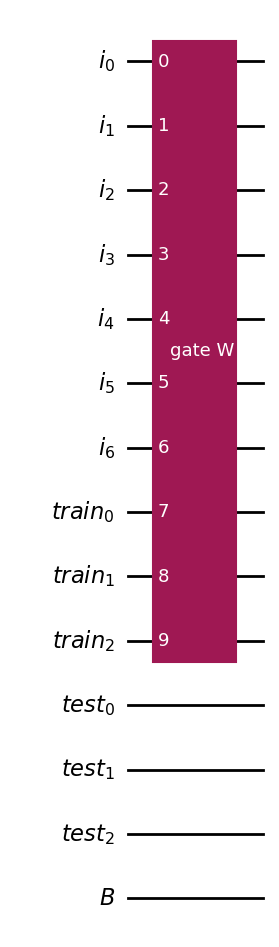

In [84]:
# Add W to the circuit
qknn.append(qc[0], list(index_reg) + list(train_reg))
qknn.draw("mpl")

In [ ]:
# # Create a list with the gates needed to create our test states
# N_test = 25
# class_list_test, V_tests = gate_V_list(N_test, train_reg)

In [ ]:
# # Save the class_list and the V gates so we can keep using the same test states
# np.save("Class list test", class_list_test)

# with open("V_gate list.qpy", "wb") as file:
#    qpy.dump(V_tests, file)

In [ ]:
# Load the V gates and the corresponsing class list
with open("V_gate list.qpy", "rb") as handle:
    qc2 = qpy.load(handle)

class_list_test = np.load("Class list test.npy")   

In [ ]:
# # Define the parameters to be used in gate V
# params_j = {"rz1": np.random.uniform(0, 2 * np.pi, size = n_qubits),
#                      "ry": np.random.uniform(0, 2 * np.pi, size = n_qubits),
#                      "rz2": np.random.uniform(0, 2 * np.pi, size = n_qubits),
#                      }
# entangled_p_j = [np.random.random_integers(0, 1)]
    
# # Create the gate V
# V = gate_V(n_qubits, params_j, 1)

\documentclass[border=2px]{standalone}

\usepackage[braket, qm]{qcircuit}
\usepackage{graphicx}

\begin{document}
\scalebox{1.0}{
\Qcircuit @C=1.0em @R=0.2em @!R { \\
	 	\nghost{{q}_{0} :  } & \lstick{{q}_{0} :  } & \gate{\mathrm{H}} & \gate{\mathrm{R_Z}\,(\mathrm{6.078})} & \gate{\mathrm{R_Y}\,(\mathrm{5.657})} & \gate{\mathrm{R_Z}\,(\mathrm{4.953})} & \ctrl{1} & \qw & \qw & \qw\\
	 	\nghost{{q}_{1} :  } & \lstick{{q}_{1} :  } & \gate{\mathrm{H}} & \gate{\mathrm{R_Z}\,(\mathrm{5.876})} & \gate{\mathrm{R_Y}\,(\mathrm{0.8473})} & \gate{\mathrm{R_Z}\,(\mathrm{1.279})} & \targ & \ctrl{1} & \qw & \qw\\
	 	\nghost{{q}_{2} :  } & \lstick{{q}_{2} :  } & \gate{\mathrm{H}} & \gate{\mathrm{R_Z}\,(\mathrm{3.855})} & \gate{\mathrm{R_Y}\,(\mathrm{3.542})} & \gate{\mathrm{R_Z}\,(\mathrm{1.79})} & \qw & \targ & \qw & \qw\\
\\ }}
\end{document}


C:\Users\lyrav\AppData\Local\Temp\ipykernel_16708\2769373975.py:6: DeprecationWarning: This function is deprecated. Please call randint(0, 1 + 1) instead
  entangled_p_j = [np.random.random_integers(0, 1)]


In [99]:
# # Save V and the entanglement class
# with open("V_gate.qpy", "wb") as file:
#      qpy.dump(V, file)

# np.save("Class list test", entangled_p_j)


In [ ]:
# # Load gate V and entanglement class
# with open("V_gate.qpy", "rb") as handle:
#     qc2 = qpy.load(handle)

# entangled_p_j = np.load("Class list test.npy")

# Visualize a gate V
print(qc2[0].draw("latex_source"))

FileNotFoundError: [Errno 2] No such file or directory: 'V_gate.qpy'

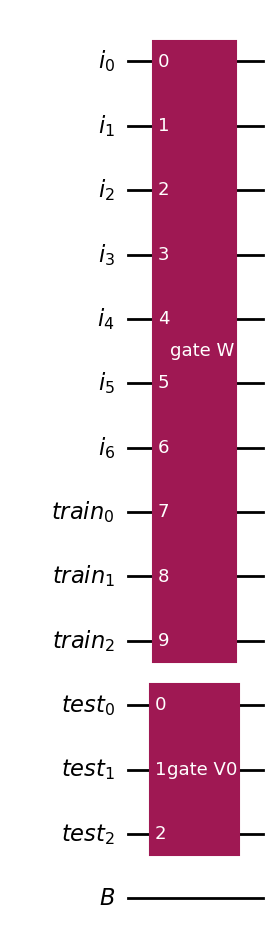

In [91]:
# Add V to the circuit
qknn.append(qc2[0], list(test_reg))
qknn.draw("mpl")